<a href="https://colab.research.google.com/github/michael-d-huynh/CPS-ABS----Labor-Force-Exposure-to-AI/blob/main/CPS_Econometrical_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
df_occ = pd.read_csv("/content/drive/MyDrive/LaborLens/df_occ.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ── prep ──────────────────────────────────────────────────────────
EDUC_TO_YEARS = {
    2:0, 10:3, 20:5, 30:7, 40:9, 50:10, 60:11,
    73:12, 81:13, 91:14, 92:14, 111:16, 123:18, 124:19, 125:20
}

AI_EXPOSED_OCC = [1005,1006,1007,1010,1021,1022,1031,1032,1050,1065,1105,1108]

df_reg = df_occ.copy()
df_reg = df_reg[df_reg["EARNWEEK"] > 0].dropna(subset=["EARNWEEK","AGE","EDUC"])

df_reg["LOG_EARN"]  = np.log(df_reg["EARNWEEK"])
df_reg["AGE2"]      = df_reg["AGE"] ** 2
df_reg["EDUC_YRS"]  = df_reg["EDUC"].map(EDUC_TO_YEARS)
df_reg["AI_FLAG"]   = df_reg["OCC"].isin(AI_EXPOSED_OCC).astype(int)
df_reg["POST"]      = (df_reg["YEAR"] > 2022).astype(int)
df_reg["TREAT"]     = df_reg["AI_FLAG"]
df_reg["DID"]       = df_reg["POST"] * df_reg["TREAT"]
df_reg = df_reg.dropna(subset=["EDUC_YRS"])

print("Regression sample:", len(df_reg))

# ── model 1: mincer OLS ───────────────────────────────────────────
ols = smf.ols(
    "LOG_EARN ~ AI_FLAG + EDUC_YRS + AGE + AGE2 + C(YEAR)",
    data=df_reg
).fit(cov_type="HC3")

coef    = ols.params["AI_FLAG"]
premium = (np.exp(coef) - 1) * 100
pval    = ols.pvalues["AI_FLAG"]
ci      = ols.conf_int().loc["AI_FLAG"]
age_peak = -ols.params["AGE"] / (2 * ols.params["AGE2"])

print("\n=== MODEL 1: MINCER OLS ===")
print(f"AI wage premium:  {premium:+.1f}%")
print(f"Coefficient β1:   {coef:.4f}")
print(f"95% CI:           [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"p-value:          {pval:.4f} {'***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.1 else 'ns'}")
print(f"R²:               {ols.rsquared:.4f}")
print(f"Edu return (β2):  {ols.params['EDUC_YRS']:.4f} per year")
print(f"Peak earn age:    {age_peak:.0f} years")

# ── model 2: difference-in-differences ───────────────────────────
did = smf.ols(
    "LOG_EARN ~ TREAT + POST + DID + EDUC_YRS + AGE + AGE2",
    data=df_reg
).fit(cov_type="HC3")

did_coef   = did.params["DID"]
did_effect = (np.exp(did_coef) - 1) * 100
did_pval   = did.pvalues["DID"]
did_ci     = did.conf_int().loc["DID"]

print("\n=== MODEL 2: DIFFERENCE-IN-DIFFERENCES ===")
print(f"DiD estimate β3:  {did_coef:.4f}")
print(f"Wage effect:      {did_effect:+.1f}%")
print(f"95% CI:           [{did_ci[0]:.4f}, {did_ci[1]:.4f}]")
print(f"p-value:          {did_pval:.4f} {'***' if did_pval<0.01 else '**' if did_pval<0.05 else '*' if did_pval<0.1 else 'ns'}")
print(f"R²:               {did.rsquared:.4f}")

# ── model 3: employment share trend ──────────────────────────────
weight_col = "ASECWT" if "ASECWT" in df_reg.columns else "WTFINL"

trend = (
    df_reg.groupby(["YEAR","AI_FLAG"])[weight_col]
    .sum().unstack().fillna(0)
)
trend.columns = ["Non-AI","AI-Exposed"]
trend["Total"]    = trend.sum(axis=1)
trend["AI_SHARE"] = (trend["AI-Exposed"] / trend["Total"] * 100).round(1)

print("\n=== MODEL 3: EMPLOYMENT SHARE TREND ===")
print(trend[["AI-Exposed","Non-AI","AI_SHARE"]])
start, end = trend["AI_SHARE"].iloc[0], trend["AI_SHARE"].iloc[-1]
print(f"\nChange 2020–2025: {start:.1f}% → {end:.1f}% ({end-start:+.1f}pp)")

Regression sample: 964

=== MODEL 1: MINCER OLS ===
AI wage premium:  +13.2%
Coefficient β1:   0.1236
95% CI:           [0.0590, 0.1881]
p-value:          0.0002 ***
R²:               0.0957
Edu return (β2):  0.0610 per year
Peak earn age:    45 years

=== MODEL 2: DIFFERENCE-IN-DIFFERENCES ===
DiD estimate β3:  -0.0569
Wage effect:      -5.5%
95% CI:           [-0.1957, 0.0820]
p-value:          0.4219 ns
R²:               0.0911

=== MODEL 3: EMPLOYMENT SHARE TREND ===
       AI-Exposed       Non-AI  AI_SHARE
YEAR                                    
2020  292660.6698  312464.5866      48.4
2021  354489.1801  282883.9144      55.6
2022  277224.3200  313282.1100      46.9
2023  277066.1700  233278.4200      54.3

Change 2020–2025: 48.4% → 54.3% (+5.9pp)


           Non-AI   AI-Exposed        Total  AI_SHARE
YEAR                                                 
2020  312464.5866  292660.6698  605125.2564      48.4
2021  282883.9144  354489.1801  637373.0945      55.6
2022  313282.1100  277224.3200  590506.4300      46.9
2023  233278.4200  277066.1700  510344.5900      54.3


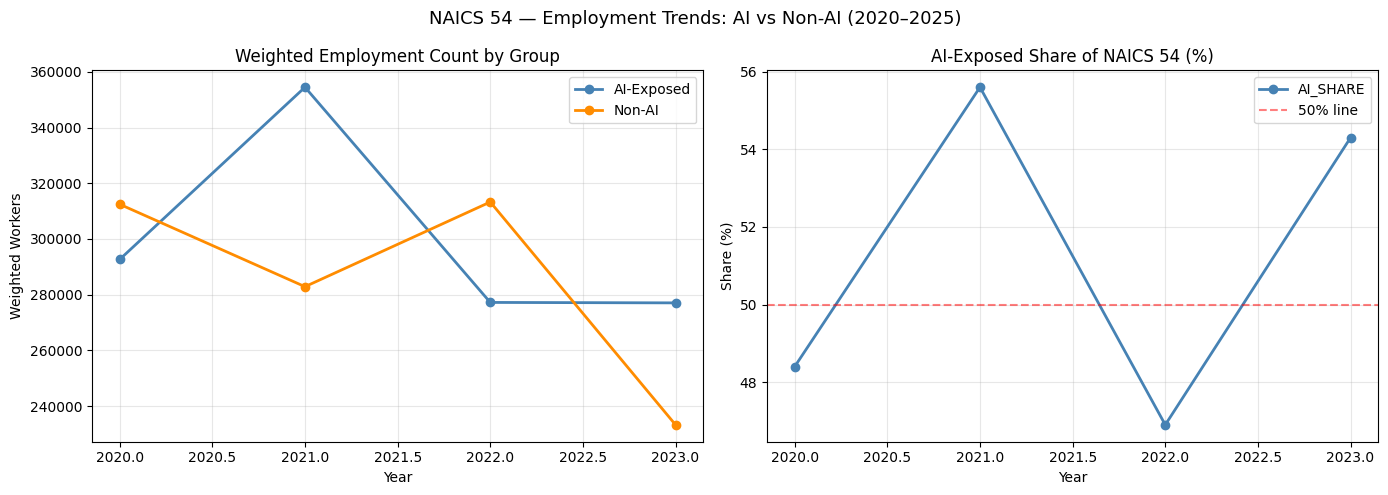

In [5]:
# Weighted employment counts by year + AI flag
weight_col = "ASECWT" if "ASECWT" in df_reg.columns else "WTFINL"

emp = (
    df_reg.groupby(["YEAR", "AI_FLAG"])[weight_col]
    .sum().unstack().fillna(0)
)
emp.columns = ["Non-AI", "AI-Exposed"]
emp["Total"]    = emp.sum(axis=1)
emp["AI_SHARE"] = (emp["AI-Exposed"] / emp["Total"] * 100).round(1)

print(emp)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: raw headcounts
emp[["AI-Exposed", "Non-AI"]].plot(
    ax=axes[0], marker="o", linewidth=2,
    color=["steelblue", "darkorange"]
)
axes[0].set_title("Weighted Employment Count by Group")
axes[0].set_ylabel("Weighted Workers")
axes[0].set_xlabel("Year")
axes[0].grid(alpha=0.3)

# Panel 2: AI share trend
emp["AI_SHARE"].plot(
    ax=axes[1], marker="o", color="steelblue", linewidth=2
)
axes[1].set_title("AI-Exposed Share of NAICS 54 (%)")
axes[1].set_ylabel("Share (%)")
axes[1].set_xlabel("Year")
axes[1].axhline(50, color="red", linestyle="--", alpha=0.5, label="50% line")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle("NAICS 54 — Employment Trends: AI vs Non-AI (2020–2025)", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
print(df_occ.columns.tolist())
print(df_occ.dtypes)

['YEAR', 'SERIAL', 'MONTH', 'CPSID', 'ASECFLAG', 'ASECWTH', 'PERNUM', 'CPSIDP', 'CPSIDV', 'ASECWT', 'AGE', 'SEX', 'RACE', 'EMPSTAT', 'OCC', 'IND', 'CLASSWKR', 'UHRSWORKT', 'EDUC', 'WKSWORK2', 'FULLPART', 'INCWAGE', 'EARNWEEK', 'OCC_LABEL']
YEAR           int64
SERIAL         int64
MONTH          int64
CPSID          int64
ASECFLAG       int64
ASECWTH      float64
PERNUM         int64
CPSIDP         int64
CPSIDV         int64
ASECWT       float64
AGE            int64
SEX            int64
RACE           int64
EMPSTAT        int64
OCC            int64
IND            int64
CLASSWKR       int64
UHRSWORKT    float64
EDUC           int64
WKSWORK2     float64
FULLPART       int64
INCWAGE        int64
EARNWEEK     float64
OCC_LABEL     object
dtype: object


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ── recode vars ───────────────────────────────────────────────────
df_occ["SEX_LABEL"] = df_occ["SEX"].map({1: "Male", 2: "Female"})

AI_EXPOSED_OCC = [1005,1006,1007,1010,1021,1022,1031,1032,1050,1065,1105,1108]
df_occ["AI_FLAG"] = df_occ["OCC"].isin(AI_EXPOSED_OCC).astype(int)

df_occ["RACE_LABEL"] = df_occ["RACE"].map({
    100: "White",
    200: "Black",
    300: "Native American",
    651: "Asian",
    652: "Asian",
    700: "Other",
    801: "White-Black",
    802: "White-Native",
    803: "White-Asian",
    804: "White-Other",
    805: "Black-Native",
    806: "Black-Asian",
    900: "Other mixed",
})

df_occ["AI_LABEL"] = df_occ["AI_FLAG"].map({1: "AI-Exposed", 0: "Non-AI"})

# ── summary tables ────────────────────────────────────────────────
print("=== GENDER × AI MEDIAN EARNWEEK ===")
gender = df_occ.groupby(["SEX_LABEL","AI_LABEL"])["EARNWEEK"].agg(["median","count"])
print(gender)

print("\n=== RACE × AI MEDIAN EARNWEEK ===")
race = df_occ.groupby(["RACE_LABEL","AI_LABEL"])["EARNWEEK"].agg(["median","count"])
print(race)

=== GENDER × AI MEDIAN EARNWEEK ===
                      median  count
SEX_LABEL AI_LABEL                 
Female    AI-Exposed  1500.0    132
          Non-AI      1250.0    227
Male      AI-Exposed  1600.0    339
          Non-AI      1654.0    267

=== RACE × AI MEDIAN EARNWEEK ===
                            median  count
RACE_LABEL      AI_LABEL                 
Asian           AI-Exposed  1682.5    124
                Non-AI      1413.5     52
Black           AI-Exposed  1519.0     36
                Non-AI      1311.5     26
Black-Asian     AI-Exposed     NaN      0
Black-Native    AI-Exposed  1500.0      1
                Non-AI         NaN      0
Native American AI-Exposed  2365.5      2
                Non-AI      1481.0      4
White           AI-Exposed  1538.0    303
                Non-AI      1538.0    403
White-Asian     AI-Exposed  1058.0      3
                Non-AI      1923.0      1
White-Black     AI-Exposed   865.0      1
                Non-AI      2365.0      1

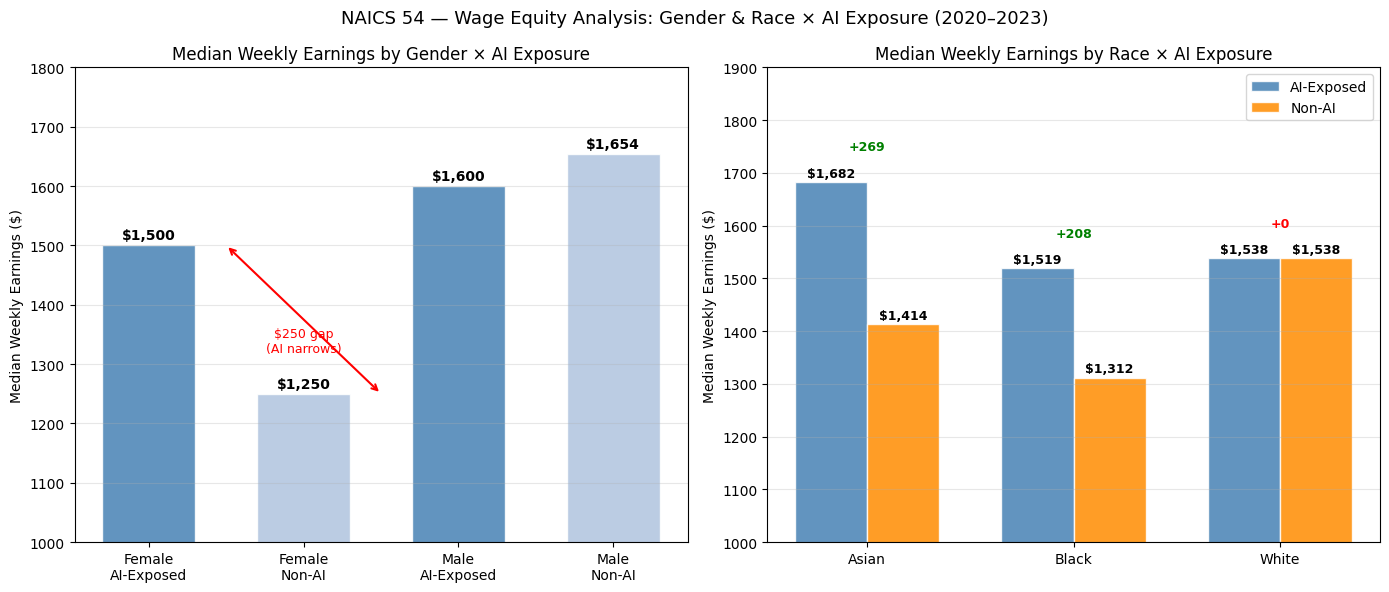

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: Gender ───────────────────────────────────────────────
gender_data = {
    "Female\nAI-Exposed": 1500,
    "Female\nNon-AI":     1250,
    "Male\nAI-Exposed":   1600,
    "Male\nNon-AI":       1654,
}
colors_gender = ["steelblue","lightsteelblue","steelblue","lightsteelblue"]
bars1 = axes[0].bar(gender_data.keys(), gender_data.values(),
                    color=colors_gender, alpha=0.85, edgecolor="white", width=0.6)
axes[0].set_title("Median Weekly Earnings by Gender × AI Exposure")
axes[0].set_ylabel("Median Weekly Earnings ($)")
axes[0].set_ylim(1000, 1800)
axes[0].grid(alpha=0.3, axis="y")
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"${bar.get_height():,.0f}", ha="center", fontsize=10, fontweight="bold")

# gender gap annotations
axes[0].annotate("", xy=(0.5, 1500), xytext=(1.5, 1250),
                 arrowprops=dict(arrowstyle="<->", color="red", lw=1.5))
axes[0].text(1.0, 1320, "$250 gap\n(AI narrows)", ha="center", fontsize=9, color="red")

# ── Panel 2: Race (reliable groups only) ─────────────────────────
race_groups = ["Asian", "Black", "White"]
ai_vals    = [1682.5, 1519.0, 1538.0]
nonai_vals = [1413.5, 1311.5, 1538.0]

x = np.arange(len(race_groups))
w = 0.35

bars_ai    = axes[1].bar(x - w/2, ai_vals,    w, label="AI-Exposed",
                          color="steelblue", alpha=0.85, edgecolor="white")
bars_nonai = axes[1].bar(x + w/2, nonai_vals, w, label="Non-AI",
                          color="darkorange", alpha=0.85, edgecolor="white")

axes[1].set_title("Median Weekly Earnings by Race × AI Exposure")
axes[1].set_ylabel("Median Weekly Earnings ($)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(race_groups)
axes[1].set_ylim(1000, 1900)
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

for bar in list(bars_ai) + list(bars_nonai):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"${bar.get_height():,.0f}", ha="center", fontsize=9, fontweight="bold")

# premium labels
for i, (ai, nonai) in enumerate(zip(ai_vals, nonai_vals)):
    delta = ai - nonai
    axes[1].text(i, max(ai, nonai) + 60,
                 f"{delta:+.0f}", ha="center", fontsize=9,
                 color="green" if delta > 0 else "red", fontweight="bold")

plt.suptitle("NAICS 54 — Wage Equity Analysis: Gender & Race × AI Exposure (2020–2023)",
             fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/LaborLens/06_equity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()